# Assignment 2 - Improvement heuristics for the Set Covering Problem (SCP)

**Course:** Heuristic Optimization &nbsp;|&nbsp; **Deadline:** 09/10/26

**Task.** Implement a **first-improvement (FI)** and a **best-improvement (BI)** iterative improvement algorithm for the SCP, using one neighbourhood of our choice and
applying **redundancy elimination (RE) after each step**. Apply each of them once to an initial solution generated by **CH1, CH2, CH3 and CH1+RE**:

$$4 \text{ initial solutions} \times 2 \text{ pivot rules} = 8 \text{ algorithms.}$$

As a variance-reduction technique FI and BI start from the **same** initial solution (same random seed for both runs on an instance).
For every algorithm we report

* the average percentage deviation from the best known solutions,
* the total computation time across all instances,
* the fraction of instances that profit from the additional local-search phase,

and interpret the results (effect of the neighbourhood design, impact of the initial solution on the local optima, FI vs. BI running times, ...).

| Step | Content |
|---|---|
| 1 | Theory: iterative improvement, neighbourhoods, first vs. best improvement, variance reduction |
| 2 | Data (OR-Library instances) |
| 3 | Solution state with incremental updates *(recap of Assignment 1)* |
| 4 | Initial solutions: CH1, CH2, CH3 and redundancy elimination *(recap of Assignment 1)* |
| 5 | **The neighbourhood and the FI / BI algorithms** |
| 6 | Experimental protocol, the 8 experiments |
| 7 | **Results:** deviation, computation time, fraction of instances that profit |
| 8 | **Interpretation:** neighbourhood design, initial solution, FI vs. BI |
| 9 | Robustness over several seeds (extra) |
| 10 | Conclusions |

Style rules as before: only plain functions (no classes), a solution state is a small dictionary of arrays,
and every function that changes the state does so **incrementally**.

## 1. Theory

### The Set Covering Problem (recap)
Given elements $A=\{a_1,\dots,a_m\}$, subsets $F=\{A_1,\dots,A_n\}$ with costs $w(A_i)>0$, find a minimum-cost $C\subseteq F$ that **covers** every element:

$$\min \sum_{i=1}^n w_i x_i \quad\text{s.t.}\quad \sum_{i=1}^n b_{ij}\,x_i \ge 1\;\;(j=1..m),\qquad x_i\in\{0,1\}.$$

### Iterative improvement
A **neighbourhood** $N(s)$ of a candidate solution $s$ is the set of solutions that can be reached from $s$ by one small change - a **move**.
Iterative improvement starts from an initial (complete, feasible) solution and repeatedly replaces the current solution by an **improving neighbour**:

```
s = initial solution
repeat
    choose s' in N(s) with f(s') < f(s)        <- the pivot rule decides WHICH improving neighbour
    s = s'
until N(s) contains no better solution          <- s is a local optimum w.r.t. N
```

Since $f$ strictly decreases and there are finitely many covers, the algorithm terminates in a **local optimum**:
a solution that is no worse than all of its neighbours (not necessarily a global optimum).

### Pivot rules: first vs. best improvement
| | First improvement (FI) | Best improvement (BI) |
|---|---|---|
| **step** | scan $N(s)$ in some (here random) order, move to the **first** improving neighbour found | evaluate **all** of $N(s)$, move to the **best** neighbour |
| **cost of one step** | between 1 and $\vert N(s)\vert$ evaluations (often much less than $\vert N(s)\vert$) | always $\vert N(s)\vert$ evaluations |
| **number of steps** | usually larger (small, "any" improvements) | usually smaller (steepest descent) |
| **randomness** | scan order -> different runs follow different paths | deterministic up to ties |

Total effort = (number of steps) $\times$ (evaluations per step) $\times$ (cost of one evaluation).
Expected behaviour: FI does more but much cheaper steps and reaches a local optimum faster; BI is not guaranteed to end in a better local optimum
(a steeper first step can lead into a worse basin), but it is often slightly better.
The local optimum reached depends on the **initial solution** and on the path, so we compare several initial solutions.

### Redundancy elimination after each step
A neighbour is evaluated **after** applying RE to it, i.e. the search always moves between *minimal* covers
(no selected set can be dropped). This makes the neighbourhood stronger: a move that creates a redundant set gets the saving "for free".
Consequence for the initial solutions: CH1, CH2 and CH3 may start with redundant sets, which RE removes in the *first* step; **CH1+RE** starts from a minimal cover.
Comparing CH1 with CH1+RE therefore isolates the effect of cleaning the start solution.

### Variance reduction: common random numbers
The heuristics are randomised (random elements, random ties, random scan order). If FI and BI started from *different* random initial solutions,
the difference of their results would mix the effect of the pivot rule with luck of the start.
Running both from `random.Random(seed)` with the **same seed** makes the construction identical, so the two algorithms start from exactly the same cover
and the per-instance difference of the results is due to the pivot rule only (a **paired** comparison; we use it in the statistical tests of Section 8).

## 2. Imports and data

In [1]:
import random
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

DATA = Path("SCP-Instances 2")   # folder with the OR-Library SCP files
SEED = 1                         # the same seed is used for every instance / algorithm

### Instance file format (OR-Library)
```
m n                      number of elements (rows) and sets (columns)
c_1 ... c_n              cost of every set
for every element i:     k_i, then the k_i sets (1-based) that cover element i
```
We keep both directions of the incidence relation, because the incremental updates need both:

* `rows_of_col[j]` - elements covered by set `j`
* `cols_of_row[e]` - sets that cover element `e`

In [2]:
def invert(lists, size):
    # 'lists[i]' holds items in range(size); return, for every item, the list of i that contain it
    out = [[] for _ in range(size)]
    for i, items in enumerate(lists):
        for x in items:
            out[x].append(i)
    return [np.array(o, dtype=np.int64) for o in out]


def build_instance(name, cost, rows_of_col, m):
    # an instance is a plain dictionary
    return {"name": name, "m": m, "n": len(cost), "cost": np.array(cost, dtype=float),
            "rows_of_col": [np.array(r, dtype=np.int64) for r in rows_of_col],
            "cols_of_row": invert(rows_of_col, m)}


def read_instance(path):
    tok = np.array(Path(path).read_text().split(), dtype=np.int64)
    m, n = tok[0], tok[1]
    cost = tok[2:2 + n]
    pos = 2 + n
    cols_of_row = []
    for _ in range(m):
        k = tok[pos]
        cols_of_row.append(tok[pos + 1:pos + 1 + k] - 1)      # to 0-based
        pos += 1 + k
    assert pos == len(tok), "unexpected data at the end of the file"
    return build_instance(Path(path).stem, cost, invert(cols_of_row, n), m)

In [3]:
def natural_key(p):
    # scp42 < scp51 < scpa1 < scpa2 ...
    return p.stem.rstrip("0123456789"), int(p.stem[len(p.stem.rstrip("0123456789")):])

files = sorted(DATA.glob("scp*.txt"), key=natural_key)
instances = [read_instance(f) for f in files]

pd.DataFrame([{"instance": i["name"], "elements m": i["m"], "sets n": i["n"],
               "avg cost": i["cost"].mean()} for i in instances]).set_index("instance").T

instance,scp42,scp43,scp44,scp45,scp46,scp47,scp48,scp49,scp51,scp52,scp53,scp54,scp55,scp56,scp57,scp58,scp59,scp61,scp62,scp63,...,scpa1,scpa2,scpa3,scpa4,scpa5,scpb1,scpb2,scpb3,scpb4,scpb5,scpc1,scpc2,scpc3,scpc4,scpc5,scpd1,scpd2,scpd3,scpd4,scpd5
elements m,200.00,200.000,200.000,200.00,200.000,200.000,200.000,200.000,200.0000,200.000,200.0000,200.000,200.0000,200.0000,200.0000,200.0000,200.000,200.00,200.00,200.000,...,300.000000,300.000000,300.000,300.000000,300.000,300.00,300.000,300.000000,300.000,300.000000,400.00000,400.00000,400.00000,400.0000,400.00000,400.0000,400.0000,400.0000,400.0000,400.0000
sets n,1000.00,1000.000,1000.000,1000.00,1000.000,1000.000,1000.000,1000.000,2000.0000,2000.000,2000.0000,2000.000,2000.0000,2000.0000,2000.0000,2000.0000,2000.000,1000.00,1000.00,1000.000,...,3000.000000,3000.000000,3000.000,3000.000000,3000.000,3000.00,3000.000,3000.000000,3000.000,3000.000000,4000.00000,4000.00000,4000.00000,4000.0000,4000.00000,4000.0000,4000.0000,4000.0000,4000.0000,4000.0000
avg cost,49.83,50.176,50.264,49.79,51.277,48.933,52.261,51.932,50.6395,51.557,49.2755,49.488,50.7675,51.5235,50.6225,50.7845,50.662,50.05,49.83,50.176,...,50.587333,50.982333,49.717,50.669333,49.867,50.63,50.652,50.988667,49.563,50.466667,50.88775,49.81325,51.09775,50.2625,50.73425,50.8935,49.9495,51.0505,50.2535,50.5205


## 3. Solution state with incremental updates *(recap of Assignment 1)*

A (partial) solution is stored together with everything the heuristics need to make their next decision:

| field | meaning | why |
|---|---|---|
| `in_sol[j]` | set `j` is selected | the solution itself |
| `cnt[e]` | how many selected sets cover element `e` | `cnt[e]==0` uncovered; a set is *redundant* iff all its elements have `cnt>=2` |
| `new_cov[j]` | number of **uncovered** elements set `j` still contains | the **dynamic** score; `new_cov[j]==0` means `j` is not a candidate (adding it would be redundant) |
| `uncovered`, `pos` | list of uncovered elements with O(1) insert / delete | to pick an uncovered element quickly |
| `cost` | total cost of the selected sets | the evaluation function value |
| `log` | list of performed `add`/`remove` operations | lets the local search **undo** a tried move without copying the state |

**Incremental update rules** (this is the core of the whole notebook):

* **add set `j`:** for every element `e` of `j` with `cnt[e]==0` (it becomes covered): remove `e` from `uncovered` and decrease `new_cov[s]` by 1 for **every set `s` that contains `e`**.
  Then `cnt[e]+=1` for all elements of `j`, and `cost += w_j`.
* **remove set `j`:** `cnt[e]-=1` for all elements of `j`; every element whose count drops to 0 becomes uncovered again,
  so add it to `uncovered` and increase `new_cov[s]` by 1 for every set `s` containing it. `cost -= w_j`.

`remove` is the exact inverse of `add`. Only the elements of `j` and the sets touching them are visited - the cost of one update is tiny compared with recomputing all scores.

In [4]:
def new_state(inst):
    # empty partial solution: nothing covered, every set could still cover all of its elements
    return {"in_sol": np.zeros(inst["n"], dtype=bool),
            "cnt": np.zeros(inst["m"], dtype=np.int64),
            "new_cov": np.array([len(r) for r in inst["rows_of_col"]], dtype=np.int64),
            "uncovered": list(range(inst["m"])),
            "pos": list(range(inst["m"])),          # pos[e] = index of e inside 'uncovered'
            "cost": 0.0,
            "log": []}


def mark_covered(st, e):
    # O(1) removal from the uncovered list: move the last element into e's slot
    i, last = st["pos"][e], st["uncovered"][-1]
    st["uncovered"][i] = last
    st["pos"][last] = i
    st["uncovered"].pop()


def mark_uncovered(st, e):
    st["pos"][e] = len(st["uncovered"])
    st["uncovered"].append(e)


def add_set(inst, st, j, log=True):
    rows = inst["rows_of_col"][j]
    for e in rows[st["cnt"][rows] == 0]:                 # elements that become covered now
        mark_covered(st, e)
        st["new_cov"][inst["cols_of_row"][e]] -= 1       # every set containing e has one uncovered element less
    st["cnt"][rows] += 1
    st["in_sol"][j] = True
    st["cost"] += inst["cost"][j]
    if log:
        st["log"].append(("add", j))


def remove_set(inst, st, j, log=True):
    rows = inst["rows_of_col"][j]
    st["cnt"][rows] -= 1
    for e in rows[st["cnt"][rows] == 0]:                 # elements that become uncovered now
        mark_uncovered(st, e)
        st["new_cov"][inst["cols_of_row"][e]] += 1
    st["in_sol"][j] = False
    st["cost"] -= inst["cost"][j]
    if log:
        st["log"].append(("remove", j))


def undo_to(inst, st, mark):
    # revert all operations after position 'mark' of the log (newest first)
    while len(st["log"]) > mark:
        op, j = st["log"].pop()
        if op == "add":
            remove_set(inst, st, j, log=False)
        else:
            add_set(inst, st, j, log=False)


def is_redundant(inst, st, j):
    # selected set j is redundant iff every element it covers is also covered by another selected set
    return bool(np.all(st["cnt"][inst["rows_of_col"][j]] >= 2))


def selected_sets(st):
    return np.flatnonzero(st["in_sol"])

### Independent check of the bookkeeping
Incremental code is easy to get subtly wrong, so we add a function that rebuilds everything **from scratch** from the list of selected sets
and compares it with the incrementally maintained values. It is called after every run in the experiments.

In [5]:
def check_state(inst, st, complete=True, minimal=False):
    # recompute counts, uncovered elements, new_cov and cost from scratch and compare
    sel = selected_sets(st)
    cnt = np.zeros(inst["m"], dtype=np.int64)
    for j in sel:
        cnt[inst["rows_of_col"][j]] += 1
    assert (cnt == st["cnt"]).all(), "cnt out of sync"
    assert set(np.flatnonzero(cnt == 0)) == set(st["uncovered"]), "uncovered list out of sync"
    new_cov = np.array([np.sum(cnt[r] == 0) for r in inst["rows_of_col"]])
    assert (new_cov == st["new_cov"]).all(), "new_cov out of sync"
    assert abs(inst["cost"][sel].sum() - st["cost"]) < 1e-6, "cost out of sync"
    if complete:
        assert (cnt > 0).all(), "not a cover"
    if minimal:
        assert not any(is_redundant(inst, st, j) for j in sel), "a redundant set is left"
    return st["cost"]

## 4. Initial solutions: constructive heuristics and RE *(recap of Assignment 1)*

### Three dynamic constructive heuristics

All three follow the same skeleton:

```
partial solution = empty
while some element is uncovered:
    choose the next set j  (rule differs)      <- the only difference between CH1, CH2, CH3
    add_set(j)                                  <- incremental update of the state
```

**No redundant set is ever added.** In CH1 and CH2 the chosen set always contains the selected uncovered element, so `new_cov >= 1`.
In CH3 only sets with `new_cov > 0` are candidates. In other words the *candidate list is dynamic*: sets whose elements are all covered already drop out automatically (their `new_cov` reaches 0).

| | which uncovered element? | which set? | information used |
|---|---|---|---|
| **CH1** | random | random set covering it | none (the example from the assignment) |
| **CH2** | random | the set covering it with the best ratio $w_j/\text{new\_cov}_j$ | cost + current coverage |
| **CH3** | implicit (all elements considered) | the best ratio $w_j/\text{new\_cov}_j$ over **all** candidate sets | cost + current coverage, global view |

CH3 is the classical **greedy heuristic of Chvatal (1979)**; it is known to have an approximation guarantee of $H(d)\le 1+\ln d$ ($d$ = size of the largest set).
CH2 is a cheaper, "element-driven" compromise: restricting the choice to sets that cover a given element makes the step cheap and keeps randomness,
but it may pick a set that is much worse than the globally best one.

Ties in the ratio are broken **randomly**, so the same seed gives the same solution but different seeds give different ones.

In [6]:
def random_uncovered(st, rng):
    return st["uncovered"][rng.randrange(len(st["uncovered"]))]


def pick_min(scores, candidates, rng):
    # index (from 'candidates') with the smallest score; ties are broken at random
    s = scores[candidates]
    best = candidates[s == s.min()]
    return int(best[rng.randrange(len(best))])


def ch1(inst, rng):
    # random uncovered element -> random set that covers it
    st = new_state(inst)
    while st["uncovered"]:
        e = random_uncovered(st, rng)
        cols = inst["cols_of_row"][e]
        add_set(inst, st, int(cols[rng.randrange(len(cols))]))
    return st


def ch2(inst, rng):
    # random uncovered element -> the set covering it with the lowest cost / new_cov
    st = new_state(inst)
    while st["uncovered"]:
        e = random_uncovered(st, rng)
        cols = inst["cols_of_row"][e]                         # all of them have new_cov >= 1
        ratio = inst["cost"][cols] / st["new_cov"][cols]      # dynamic score, always up to date
        best = cols[ratio == ratio.min()]
        add_set(inst, st, int(best[rng.randrange(len(best))]))
    return st


def greedy_complete(inst, st, rng, banned=-1):
    # complete ANY partial solution with the dynamic greedy rule of CH3.
    # 'banned' = a set that must not be chosen (used later by the neighbourhood move)
    while st["uncovered"]:
        cand = np.flatnonzero(st["new_cov"] > 0)              # dynamic candidate list
        if banned >= 0 and len(cand) > 1:
            cand = cand[cand != banned]
        ratio = inst["cost"] / np.maximum(st["new_cov"], 1)
        add_set(inst, st, pick_min(ratio, cand, rng))
    return st


def ch3(inst, rng):
    # Chvatal greedy = complete the empty solution with the dynamic greedy rule
    return greedy_complete(inst, new_state(inst), rng)


CONSTRUCTIVE = {"CH1": ch1, "CH2": ch2, "CH3": ch3}

### Redundancy elimination (RE)

**Why it is needed.** The construction only guarantees that a set was *useful when it was added*.
Later sets may cover all its elements, so in the complete cover it can be redundant: removing it keeps the cover feasible and **strictly decreases the cost** (all costs are positive).

**Procedure.**
1. Order the selected sets by **decreasing cost** - the most expensive redundant set is the most profitable one to drop (ties: random).
2. For each set in this order: if all its elements have `cnt >= 2`, remove it (incremental `remove_set`).

**One pass is enough.** Removing a set can only *lower* the counts `cnt`, so a set that was not redundant when examined can never become redundant later.
After the pass no redundant set is left (the cover is *minimal*, not necessarily minimum). Note that the order matters for the result, which is why we use the cost order.

RE is in fact already a tiny local search with the neighbourhood "drop one set" - we generalise this idea in Section 5, where RE is applied after every step.

In [7]:
def redundancy_elimination(inst, st, rng):
    sel = list(selected_sets(st))
    rng.shuffle(sel)                                  # random order first ...
    sel.sort(key=lambda j: -inst["cost"][j])          # ... then by decreasing cost (sort is stable -> random ties)
    removed = 0
    for j in sel:
        if is_redundant(inst, st, j):
            remove_set(inst, st, j)
            removed += 1
    return removed

## 5. The neighbourhood and the FI / BI algorithms

### Neighbourhood: drop one set and repair
For a minimal cover $S$ and a selected set $j\in S$ the neighbour $S_j$ is obtained by

1. **remove** $j$ from the cover - the elements that only $j$ covered become uncovered;
2. **repair** the cover with the dynamic greedy rule of CH3 (cheapest cost per newly covered element), with $j$ **forbidden** so that we really leave $S$;
3. **redundancy elimination** on the result (the repair may have made other sets redundant).

$$N(S)=\{\,\text{RE}(\text{repair}(S\setminus\{j\})) \;:\; j\in S\,\}, \qquad |N(S)| = |S| .$$

Why this neighbourhood?

* **Every neighbour is a feasible, minimal cover**, so no infeasible solutions have to be handled and the objective alone guides the search.
* **It is "large" in effect but small in size.** One move can replace one expensive set by several cheap ones (or the other way round), which a plain
  swap of *one* set for *one* set cannot do: a single set that covers everything $j$ covered *alone* rarely exists, because the sets are small (2-5 % of the elements).
* **It is cheap.** $|N(S)|$ equals the number of selected sets (tens to about a hundred), and every neighbour is built and evaluated
  with the incremental `remove_set` / `add_set` operations and then **undone** from the log - the state is never copied or recomputed.
* The repair is greedy, so a neighbour is determined by $j$ up to random tie-breaking. When BI selects the best neighbour we **replay the logged operations**
  of exactly that neighbour, so the evaluated and the applied neighbour are identical.

### FI and BI
Both use the same move (`apply_drop_and_repair`) and the same bookkeeping and differ only in the pivot rule:

* **FI:** scan the selected sets in random order, accept the first neighbour with a strictly smaller cost, restart the scan from the new solution.
* **BI:** evaluate all neighbours, accept the best one if it is strictly better than the current solution.
* Both stop when no neighbour is strictly better (local optimum). We count the **steps** (accepted moves), the **evaluations** (neighbours built) and the **improving neighbours seen**,
  and record the cost after every step, which we need for the interpretation.

In [8]:
def apply_drop_and_repair(inst, st, j, rng):
    # one step of the neighbourhood: drop j, repair greedily (without j), remove redundant sets
    remove_set(inst, st, j)
    greedy_complete(inst, st, rng, banned=j)
    redundancy_elimination(inst, st, rng)


def replay(inst, st, ops):
    for op, j in ops:
        add_set(inst, st, j) if op == "add" else remove_set(inst, st, j)


def local_search(inst, st, rng, pivot):
    # iterative improvement; pivot = "first" (FI) or "best" (BI). Modifies 'st' in place.
    moves = evals = improving = 0
    trace = [(0, st["cost"])]                                 # (evaluations so far, cost) after every accepted step
    while True:
        st["log"].clear()
        current = st["cost"]
        best_cost, best_ops = current, None
        neighbours = list(selected_sets(st))
        rng.shuffle(neighbours)                               # random scan order
        for j in neighbours:
            mark = len(st["log"])
            apply_drop_and_repair(inst, st, j, rng)           # build the neighbour incrementally ...
            evals += 1
            if st["cost"] < current - 1e-9:                   # ... strictly better than the current solution?
                improving += 1
                if pivot == "first":
                    best_ops = []                             # FI: keep it, the state already is the neighbour
                    break
                if st["cost"] < best_cost - 1e-9:             # BI: remember the operations of the best one so far
                    best_cost, best_ops = st["cost"], list(st["log"][mark:])
            undo_to(inst, st, mark)                           # not accepted -> undo incrementally
        if best_ops is None:                                  # no improving neighbour: local optimum
            break
        if pivot == "best":
            replay(inst, st, best_ops)                        # BI: apply the best neighbour found
        moves += 1
        trace.append((evals, st["cost"]))
    # Safety net: RE is applied after every step; this call only matters if the very first
    # scan found no improving neighbour although the start cover had redundant sets.
    final_re = redundancy_elimination(inst, st, rng)
    return {"moves": moves, "evals": evals, "improving": improving, "final_re": final_re, "trace": trace}

### Walk-through on the toy example
$A=\{a,\dots,g\}$ with six sets of costs $6,3,5,4,5,4$ (the example from the lectures).
We start from a CH1 cover and print the whole neighbourhood: for each selected set the neighbour (after repair and RE) and its cost.

In [9]:
letters = "abcdefg"
toy_sets = ["abdg", "abc", "efg", "fg", "de", "cd"]
toy = build_instance("toy", [6, 3, 5, 4, 5, 4], [[letters.index(x) for x in s] for s in toy_sets], m=7)

def names(st):
    return "{" + ", ".join(f"A{j+1}" for j in selected_sets(st)) + "}"

rng = random.Random(3)
st = ch1(toy, rng)
redundancy_elimination(toy, st, rng)
print("start (CH1 + RE):", names(st), " cost", st["cost"])
for j in list(selected_sets(st)):                       # the whole neighbourhood of the start cover
    mark = len(st["log"])
    apply_drop_and_repair(toy, st, j, rng)
    print(f"  drop A{j+1:<2d} -> neighbour {names(st):18s} cost {st['cost']:.0f}")
    undo_to(toy, st, mark)                              # back to the start cover
info = local_search(toy, st, rng, "best")
print("best-improvement local search ->", names(st), " cost", st["cost"], f"({info['moves']} steps, {info['evals']} evaluations)")
check_state(toy, st, minimal=True);

start (CH1 + RE): {A1, A3, A6}  cost 15.0
  drop A1  -> neighbour {A2, A3, A6}       cost 12
  drop A3  -> neighbour {A1, A4, A5, A6}   cost 19
  drop A6  -> neighbour {A1, A2, A3}       cost 14
best-improvement local search -> {A2, A3, A6}  cost 12.0 (1 steps, 6 evaluations)


### Test on one real instance
Before running everything: both algorithms must return a valid, minimal cover that is never worse than the start,
and the incremental bookkeeping must still agree with a from-scratch recomputation after thousands of `add` / `remove` / `undo` operations.

In [10]:
inst = instances[0]                     # scp42
for pivot in ["first", "best"]:
    rng = random.Random(SEED)
    st = ch1(inst, rng)
    start = st["cost"]
    t0 = time.perf_counter()
    s = local_search(inst, st, rng, pivot)
    check_state(inst, st, minimal=True)
    print(f"{inst['name']} CH1 -> {pivot:5s}: {start:.0f} -> {st['cost']:.0f} in {s['moves']} steps, {s['evals']} evaluations, "
          f"{time.perf_counter() - t0:.2f}s")

scp42 CH1 -> first: 4544 -> 523 in 63 steps, 316 evaluations, 0.16s


scp42 CH1 -> best : 4544 -> 522 in 36 steps, 2394 evaluations, 0.61s


## 6. Experimental protocol

* **8 algorithms** = {CH1, CH2, CH3, CH1+RE} $\times$ {FI, BI}; each is applied **once** to every instance.
* Every run on an instance starts from `random.Random(SEED)`. The construction (and for CH1+RE the RE) consumes the random numbers first, so FI and BI get **the same initial solution**
  and also the same state of the random number generator when the local search begins. The code asserts that the two initial costs are identical.
* The time is measured with `time.perf_counter()` and split into the construction (incl. RE for CH1+RE) and the local search. The verification (`check_state`) is not timed.
* After each run `check_state` verifies feasibility, cost and minimality of the local optimum.

**Measures** for an instance $i$ with initial cost $f_i^0$, final cost $f_i$ and best known cost $b_i$:

$$\text{dev}_i = 100\cdot\frac{f_i-b_i}{b_i}\;[\%],\qquad
\overline{\text{dev}}=\frac1{|I|}\sum_i \text{dev}_i,\qquad
\text{fraction that profits}=\frac{|\{i: f_i<f_i^0\}|}{|I|},$$

and the total computation time $\sum_i t_i$ over all instances.

In [11]:
START = {"CH1": ("CH1", False), "CH2": ("CH2", False), "CH3": ("CH3", False), "CH1+RE": ("CH1", True)}
PIVOT = {"first": "FI", "best": "BI"}


def run_algorithm(inst, start, pivot, seed):
    # initial solution (same seed -> identical for FI and BI), then iterative improvement
    rng = random.Random(seed)
    method, with_re = START[start]
    t0 = time.perf_counter()
    st = CONSTRUCTIVE[method](inst, rng)
    if with_re:
        redundancy_elimination(inst, st, rng)
    t1 = time.perf_counter()
    cost_init = check_state(inst, st)                         # (not timed)
    t2 = time.perf_counter()
    s = local_search(inst, st, rng, pivot)
    t3 = time.perf_counter()
    cost_final = check_state(inst, st, minimal=True)          # (not timed)
    return {"cost_init": cost_init, "cost_final": cost_final, "sec_init": t1 - t0, "sec_ls": t3 - t2, **s}


def run_all(seed):
    rows = []
    for inst in instances:
        for start in START:
            pair = {}
            for pivot in PIVOT:
                r = run_algorithm(inst, start, pivot, seed)
                pair[pivot] = r
                rows.append({"instance": inst["name"], "start": start, "pivot": PIVOT[pivot], "seed": seed, **r})
            # variance reduction check: FI and BI really started from the same solution
            assert pair["first"]["cost_init"] == pair["best"]["cost_init"], "FI and BI started from different solutions"
    return pd.DataFrame(rows)


t0 = time.perf_counter()
res = run_all(SEED)
print(f"8 algorithms x {len(instances)} instances done in {time.perf_counter() - t0:.0f} s")
res["group"] = res.instance.str.extract(r"scp(\d|[a-d])")[0].str.upper()
res["alg"] = res.start + " + " + res["pivot"]
res["profited"] = res.cost_final < res.cost_init
res["sec_total"] = res.sec_init + res.sec_ls
print("safety-net RE was needed in", int((res.final_re > 0).sum()), "of", len(res), "runs")
res.drop(columns="trace").head(8)

8 algorithms x 42 instances done in 69 s
safety-net RE was needed in 0 of 336 runs


,instance,start,pivot,seed,cost_init,cost_final,sec_init,sec_ls,moves,evals,improving,final_re,group,alg,profited,sec_total
0,scp42,CH1,FI,1,4544.0,523.0,0.000622,0.076031,63,316,63,0,4,CH1 + FI,True,0.076653
1,scp42,CH1,BI,1,4544.0,522.0,0.000607,0.577655,36,2394,945,0,4,CH1 + BI,True,0.578262
2,scp42,CH2,FI,1,580.0,526.0,0.000774,0.045173,8,191,8,0,4,CH2 + FI,True,0.045948
3,scp42,CH2,BI,1,580.0,526.0,0.000752,0.061142,3,257,66,0,4,CH2 + BI,True,0.061894
4,scp42,CH3,FI,1,590.0,536.0,0.001411,0.024277,6,102,6,0,4,CH3 + FI,True,0.025688
5,scp42,CH3,BI,1,590.0,536.0,0.001294,0.086230,4,335,85,0,4,CH3 + BI,True,0.087524
6,scp42,CH1+RE,FI,1,2990.0,551.0,0.000923,0.067544,52,290,52,0,4,CH1+RE + FI,True,0.068467
7,scp42,CH1+RE,BI,1,2990.0,528.0,0.000940,0.507165,33,2174,891,0,4,CH1+RE + BI,True,0.508105


## 7. Results

### Best known solutions
`SCP-Instances 2/best_solution.txt` holds the best known cost per instance (one line `<set>.<number> <cost>`, e.g. `4.2 512`, `A.1 253`;
we translate the label into the instance name `scp42`, `scpa1`). The file also lists scp41, scp410 and scp510, which are not in the instance folder and are ignored.

In [12]:
def read_best(path):
    # 'label cost' per line;  '4.2' -> 'scp42',  '5.10' -> 'scp510',  'A.1' -> 'scpa1'
    best = {}
    for line in Path(path).read_text().splitlines():
        if line.strip():
            label, value = line.split()
            group, number = label.split(".")
            best["scp" + group.lower() + number] = int(value)
    return best


BEST = read_best(DATA / "best_solution.txt")
assert all(i["name"] in BEST for i in instances)

def dev(cost, best):
    return 100.0 * (cost - best) / best

res["best"] = res.instance.map(BEST)
res["dev_init"] = dev(res.cost_init, res.best)
res["dev_final"] = dev(res.cost_final, res.best)
assert (res.dev_final >= -1e-9).all(), "a local optimum is better than the best known solution - check data/code"

### Main table: the 8 algorithms

In [13]:
ALG_ORDER = [f"{s} + {p}" for s in START for p in ["FI", "BI"]]
g = res.groupby("alg")
main = pd.DataFrame({
    "avg dev % (initial)":  g.dev_init.mean(),
    "avg dev % (final)":    g.dev_final.mean(),
    "fraction profiting":   g.profited.mean(),
    "# profiting":          g.profited.sum().astype(int),
    "total time LS [s]":    g.sec_ls.sum(),
    "total time incl. start [s]": g.sec_total.sum(),
}).loc[ALG_ORDER]
main.round(3)

,avg dev % (initial),avg dev % (final),fraction profiting,# profiting,total time LS [s],total time incl. start [s]
alg,,,,,,
CH1 + FI,2297.068,3.527,1.0,42,3.130,3.172
CH1 + BI,2297.068,4.168,1.0,42,23.641,23.675
CH2 + FI,19.451,3.857,1.0,42,1.777,1.819
CH2 + BI,19.451,3.983,1.0,42,4.548,4.589
CH3 + FI,13.050,2.856,1.0,42,1.443,1.517
CH3 + BI,13.050,2.629,1.0,42,3.314,3.386
CH1+RE + FI,1755.704,4.495,1.0,42,3.184,3.231
CH1+RE + BI,1755.704,3.748,1.0,42,23.340,23.385


### What the search mechanics look like
Average number of accepted steps and evaluated neighbours per instance, share of evaluated neighbours that were strictly improving,
and the time per evaluated neighbour (one evaluation = build the neighbour incrementally, read its cost, undo it).

In [14]:
g = res.groupby("alg")
mech = pd.DataFrame({
    "avg steps":              g.moves.mean(),
    "avg evaluations":        g.evals.mean(),
    "improving / evaluated":  g.improving.sum() / g.evals.sum(),
    "avg evals per step":     g.evals.sum() / g.moves.sum(),
    "ms per evaluation":      1000 * g.sec_ls.sum() / g.evals.sum(),
}).loc[ALG_ORDER]
mech.round(3)

,avg steps,avg evaluations,improving / evaluated,avg evals per step,ms per evaluation
alg,,,,,
CH1 + FI,56.167,294.095,0.191,5.236,0.253
CH1 + BI,32.786,2146.786,0.436,65.479,0.262
CH2 + FI,9.619,168.643,0.057,17.532,0.251
CH2 + BI,5.714,414.857,0.181,72.600,0.261
CH3 + FI,5.548,134.071,0.041,24.167,0.256
CH3 + BI,3.333,286.214,0.248,85.864,0.276
CH1+RE + FI,54.000,298.500,0.181,5.528,0.254
CH1+RE + BI,32.429,2101.024,0.431,64.789,0.264


### Charts: quality and computation time

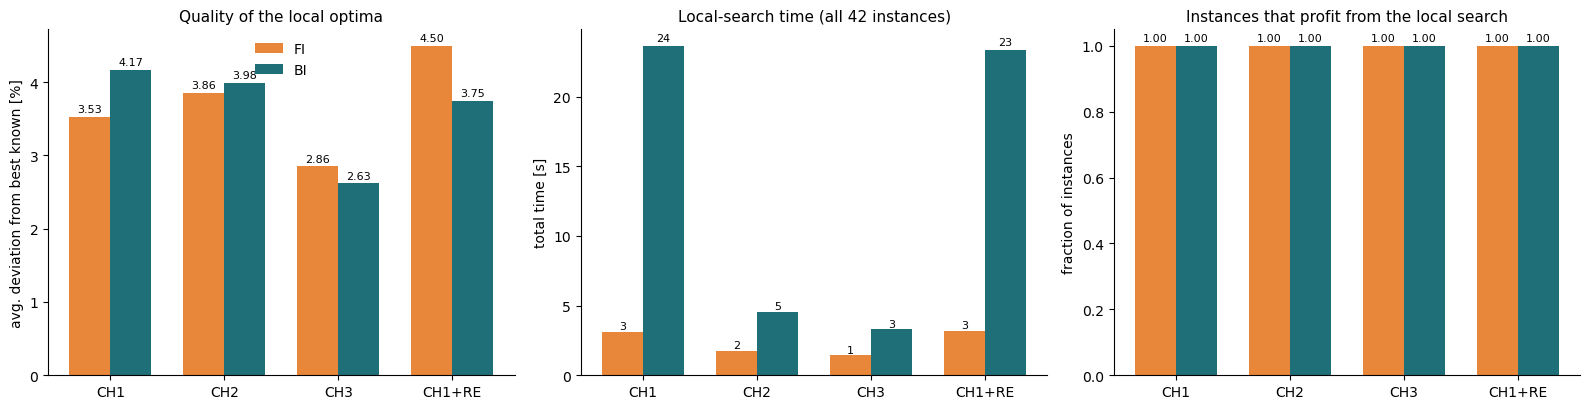

In [15]:
COL = {"FI": "#e8873a", "BI": "#1f6f78"}
starts = list(START)
x = np.arange(len(starts)); w = 0.36

fig, axs = plt.subplots(1, 3, figsize=(16, 4.2))
for k, (metric, title, ylabel) in enumerate([("avg dev % (final)", "Quality of the local optima", "avg. deviation from best known [%]"),
                                             ("total time LS [s]", "Local-search time (all 42 instances)", "total time [s]"),
                                             ("fraction profiting", "Instances that profit from the local search", "fraction of instances")]):
    for off, p in zip([-w/2, w/2], ["FI", "BI"]):
        vals = [main.loc[f"{s} + {p}", metric] for s in starts]
        bars = axs[k].bar(x + off, vals, w, label=p, color=COL[p])
        for r in bars:
            axs[k].text(r.get_x() + r.get_width()/2, r.get_height() * 1.01, f"{r.get_height():.2f}" if metric != "total time LS [s]" else f"{r.get_height():.0f}",
                        ha="center", va="bottom", fontsize=8)
    axs[k].set_xticks(x); axs[k].set_xticklabels(starts); axs[k].set_title(title, fontsize=11); axs[k].set_ylabel(ylabel)
    axs[k].spines[["top", "right"]].set_visible(False)
axs[0].legend(frameon=False)
plt.tight_layout(); plt.show()

### Initial solution vs. local optimum
The deviation before and after the local search (log scale) shows how much of the gap the local search closes and how much of the start quality survives.

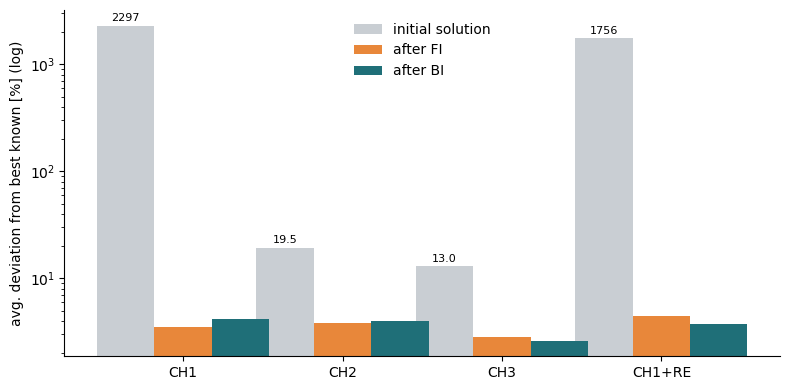

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
init = [main.loc[f"{s} + FI", "avg dev % (initial)"] for s in starts]
ax.bar(x - w, init, w, color="#c9ced3", label="initial solution")
for off, p in zip([0, w], ["FI", "BI"]):
    ax.bar(x + off, [main.loc[f"{s} + {p}", "avg dev % (final)"] for s in starts], w, color=COL[p], label=f"after {p}")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(starts)
ax.set_ylabel("avg. deviation from best known [%] (log)"); ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
for i, v in enumerate(init):
    ax.text(x[i] - w, v * 1.1, f"{v:.0f}" if v >= 100 else f"{v:.1f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

### Per-instance results (final cost of the 8 algorithms)

In [17]:
tab = res.pivot(index="instance", columns="alg", values="cost_final")[ALG_ORDER].astype(int)
tab.insert(0, "best known", pd.Series(BEST))
tab.loc[[i["name"] for i in instances]]

alg,best known,CH1 + FI,CH1 + BI,CH2 + FI,CH2 + BI,CH3 + FI,CH3 + BI,CH1+RE + FI,CH1+RE + BI
instance,,,,,,,,,
scp42,512,523,522,526,526,536,536,551,528
scp43,516,522,520,560,520,523,520,523,537
scp44,494,517,504,518,519,504,499,512,505
scp45,512,523,526,522,522,518,514,522,525
scp46,560,563,568,564,564,565,565,562,568
scp47,430,443,434,443,444,432,432,444,437
scp48,492,499,497,495,495,493,493,497,497
scp49,641,671,667,677,674,664,653,667,677
scp51,253,265,271,267,267,259,258,272,255


### Average deviation by instance set (final solutions)

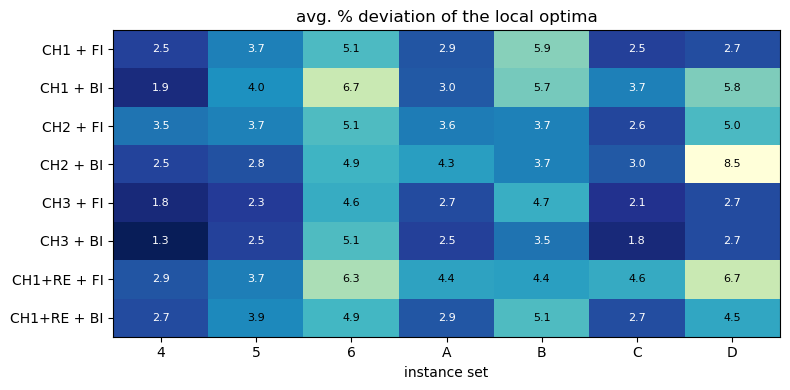

group,4,5,6,A,B,C,D
alg,,,,,,,
CH1 + FI,2.47,3.69,5.06,2.89,5.87,2.45,2.75
CH1 + BI,1.86,4.01,6.73,2.99,5.65,3.68,5.77
CH2 + FI,3.50,3.72,5.10,3.64,3.73,2.59,5.04
CH2 + BI,2.53,2.81,4.86,4.30,3.72,2.98,8.49
CH3 + FI,1.80,2.34,4.64,2.72,4.72,2.13,2.70
CH3 + BI,1.29,2.49,5.09,2.46,3.46,1.81,2.72
CH1+RE + FI,2.91,3.68,6.35,4.43,4.35,4.63,6.73
CH1+RE + BI,2.71,3.86,4.94,2.92,5.11,2.73,4.51


In [18]:
order = ["4", "5", "6", "A", "B", "C", "D"]
by_group = res.groupby(["alg", "group"]).dev_final.mean().unstack()[order].loc[ALG_ORDER]
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(by_group.values, cmap="YlGnBu_r", aspect="auto")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order); ax.set_yticks(range(len(ALG_ORDER))); ax.set_yticklabels(ALG_ORDER)
for i in range(by_group.shape[0]):
    for j in range(by_group.shape[1]):
        ax.text(j, i, f"{by_group.values[i, j]:.1f}", ha="center", va="center", fontsize=8,
                color="white" if by_group.values[i, j] < by_group.values.mean() else "black")
ax.set_xlabel("instance set"); ax.set_title("avg. % deviation of the local optima")
plt.tight_layout(); plt.show()
by_group.round(2)

### Computation time statistics
The total time of the main table hides how the time is distributed. For every algorithm we report the **local-search time per instance** (mean, median, maximum, slowest instance)
and the share of the construction in the total time; then how the time depends on the **instance set** and on the **size** of the instance, and finally the **quality-time trade-off**
(which algorithms are *not dominated*, i.e. no other algorithm is both faster and better).

In [19]:
size = {i["name"]: i["m"] * i["n"] for i in instances}
res["size"] = res.instance.map(size)

g = res.groupby("alg")
time_stats = pd.DataFrame({
    "total LS [s]":            g.sec_ls.sum(),
    "mean per instance [s]":   g.sec_ls.mean(),
    "median per instance [s]": g.sec_ls.median(),
    "max per instance [s]":    g.sec_ls.max(),
    "slowest instance":        res.loc[g.sec_ls.idxmax()].set_index("alg").instance,
    "construction share [%]":  100 * g.sec_init.sum() / g.sec_total.sum(),
}).loc[ALG_ORDER]
time_stats.round(3)

,total LS [s],mean per instance [s],median per instance [s],max per instance [s],slowest instance,construction share [%]
alg,,,,,,
CH1 + FI,3.130,0.075,0.069,0.210,scpc1,1.349
CH1 + BI,23.641,0.563,0.576,1.322,scpc3,0.142
CH2 + FI,1.777,0.042,0.038,0.102,scpc3,2.317
CH2 + BI,4.548,0.108,0.098,0.300,scp46,0.897
CH3 + FI,1.443,0.034,0.030,0.084,scpc5,4.835
CH3 + BI,3.314,0.079,0.064,0.242,scpc4,2.152
CH1+RE + FI,3.184,0.076,0.071,0.231,scpc2,1.439
CH1+RE + BI,23.340,0.556,0.562,1.343,scpc2,0.195


**Mean local-search time per instance [s] by instance set**

In [20]:
order = ["4", "5", "6", "A", "B", "C", "D"]
time_by_group = res.groupby(["alg", "group"]).sec_ls.mean().unstack()[order].loc[ALG_ORDER]
time_by_group.round(3)

group,4,5,6,A,B,C,D
alg,,,,,,,
CH1 + FI,0.074,0.075,0.032,0.102,0.036,0.156,0.047
CH1 + BI,0.585,0.603,0.150,0.827,0.218,1.249,0.263
CH2 + FI,0.054,0.041,0.019,0.061,0.019,0.070,0.025
CH2 + BI,0.149,0.117,0.035,0.158,0.041,0.188,0.038
CH3 + FI,0.037,0.036,0.011,0.048,0.016,0.069,0.021
CH3 + BI,0.088,0.072,0.022,0.119,0.026,0.186,0.038
CH1+RE + FI,0.081,0.083,0.027,0.090,0.045,0.155,0.041
CH1+RE + BI,0.591,0.582,0.142,0.838,0.259,1.165,0.271


**How does the time scale?** Spearman rank correlation, over the 42 instances, of the local-search time with the number of evaluated neighbours and with the instance size $m\cdot n$;
and the cost of one evaluated neighbour (ms) for each instance set.

In [21]:
rows = []
for a in ALG_ORDER:
    d = res[res.alg == a]
    rows.append({"alg": a,
                 "rho(time, evaluations)": stats.spearmanr(d.sec_ls, d.evals)[0],
                 "rho(time, size m*n)": stats.spearmanr(d.sec_ls, d["size"])[0]})
pd.DataFrame(rows).set_index("alg").round(3)

,"rho(time, evaluations)","rho(time, size m*n)"
alg,,
CH1 + FI,0.977,0.233
CH1 + BI,0.995,0.303
CH2 + FI,0.961,0.024
CH2 + BI,0.977,0.018
CH3 + FI,0.985,0.216
CH3 + BI,0.990,0.205
CH1+RE + FI,0.961,0.185
CH1+RE + BI,0.975,0.295


In [22]:
g = res.groupby("group")
per_eval = pd.DataFrame({"m x n": g["size"].first(),
                         "ms per evaluated neighbour": 1000 * g.sec_ls.sum() / g.evals.sum()}).loc[order]
per_eval.round(3)

,m x n,ms per evaluated neighbour
group,,
4,200000,0.247
5,400000,0.244
6,200000,0.179
A,900000,0.288
B,900000,0.231
C,1600000,0.318
D,1600000,0.234


not dominated (faster or better than every other algorithm): ['CH3 + FI', 'CH3 + BI']


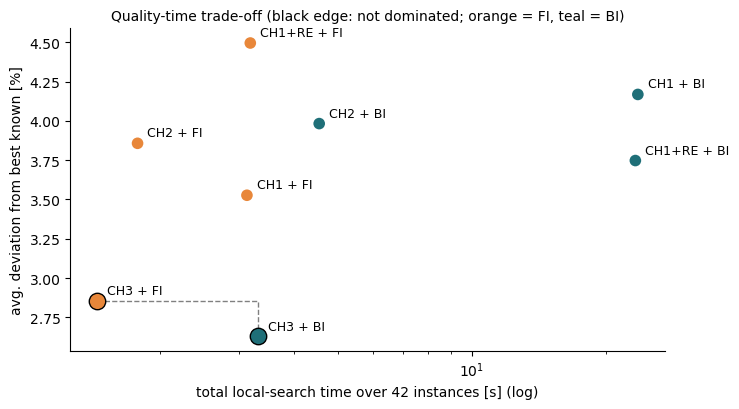

In [23]:
tr = main[["total time LS [s]", "avg dev % (final)"]]
dominated = lambda a: ((tr["total time LS [s]"] <= tr.loc[a, "total time LS [s]"]) & (tr["avg dev % (final)"] <= tr.loc[a, "avg dev % (final)"]) & (tr.index != a)).any()
pareto = [a for a in tr.index if not dominated(a)]
print("not dominated (faster or better than every other algorithm):", pareto)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for a in tr.index:
    start, p = a.split(" + ")[0], a.split(" + ")[-1]
    ax.scatter(tr.loc[a, "total time LS [s]"], tr.loc[a, "avg dev % (final)"], s=140 if a in pareto else 70, color=COL[p],
               edgecolor="black" if a in pareto else "none", zorder=3)
    ax.annotate(a, (tr.loc[a, "total time LS [s]"], tr.loc[a, "avg dev % (final)"]), xytext=(7, 5), textcoords="offset points", fontsize=9)
front = tr.loc[pareto].sort_values("total time LS [s]")
ax.step(front["total time LS [s]"], front["avg dev % (final)"], where="post", color="grey", ls="--", lw=1, zorder=1)
ax.set_xscale("log"); ax.set_xlabel("total local-search time over 42 instances [s] (log)"); ax.set_ylabel("avg. deviation from best known [%]")
ax.set_title("Quality-time trade-off (black edge: not dominated; orange = FI, teal = BI)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Interpretation

We look at four questions and check them against what we expected from the theory in Section 1.

1. **Does the neighbourhood work as intended?** (every start profits? how much does a step give? what do the steps cost?)
2. **How does the initial solution influence the local optimum?** (quality and effort)
3. **FI vs. BI:** quality of the local optima and computation time.
4. **Is the observed difference real or noise?** (paired statistical tests over the instances)

### 8.1 Convergence: cost against effort
Cost after every accepted step, plotted against the number of **evaluated neighbours** (the fair measure of effort) on one instance. FI makes many cheap steps, BI few expensive ones.

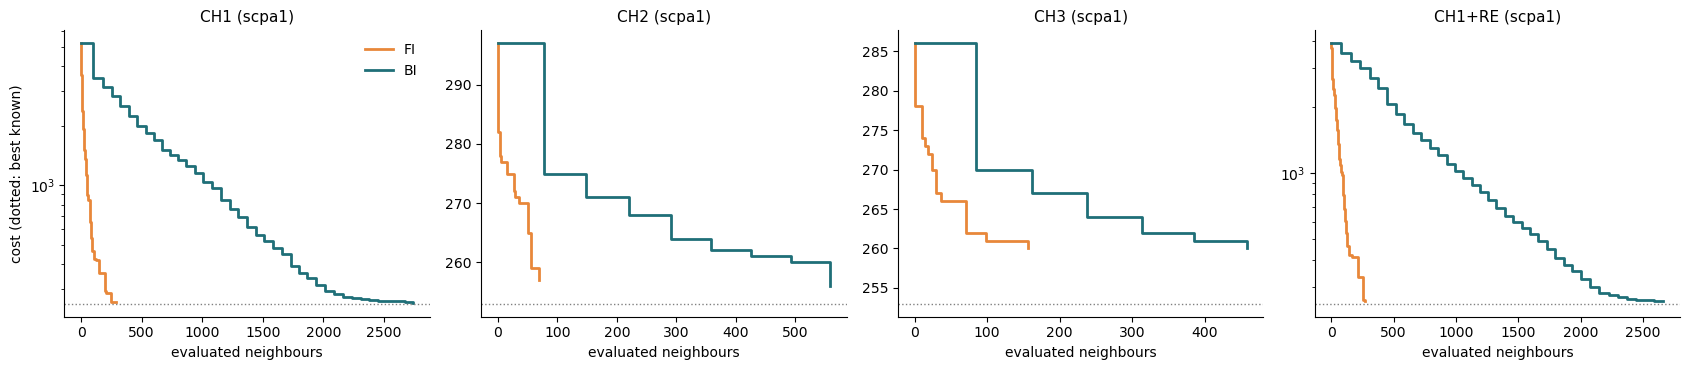

In [24]:
name = "scpa1"
fig, axs = plt.subplots(1, 4, figsize=(17, 3.8), sharey=False)
for ax, start in zip(axs, START):
    for p in ["FI", "BI"]:
        tr = res[(res.instance == name) & (res.start == start) & (res["pivot"] == p)].trace.iloc[0]
        ax.step([t[0] for t in tr], [t[1] for t in tr], where="post", color=COL[p], lw=2, label=p)
    ax.axhline(BEST[name], color="grey", ls=":", lw=1)
    if start in ("CH1", "CH1+RE"):
        ax.set_yscale("log")
    ax.set_title(f"{start} ({name})", fontsize=11); ax.set_xlabel("evaluated neighbours")
    ax.spines[["top", "right"]].set_visible(False)
axs[0].set_ylabel("cost (dotted: best known)"); axs[0].legend(frameon=False)
plt.tight_layout(); plt.show()

### 8.2 FI vs. BI per instance
For each initial solution: on how many instances is FI strictly better, equal, or strictly worse than BI (final cost), the average ratio of the running times,
and the **Wilcoxon signed-rank test** on the paired final deviations (paired because FI and BI start from the same solution).

In [25]:
def paired_p(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return 1.0 if np.allclose(a, b) else stats.wilcoxon(a, b).pvalue

rows = []
for s in START:
    fi = res[(res.start == s) & (res["pivot"] == "FI")].set_index("instance")
    bi = res[(res.start == s) & (res["pivot"] == "BI")].set_index("instance")
    rows.append({"start": s,
                 "FI better": int((fi.cost_final < bi.cost_final).sum()),
                 "equal": int((fi.cost_final == bi.cost_final).sum()),
                 "BI better": int((fi.cost_final > bi.cost_final).sum()),
                 "avg dev FI - BI [pp]": (fi.dev_final - bi.dev_final).mean(),
                 "Wilcoxon p (dev)": paired_p(fi.dev_final, bi.dev_final),
                 "time BI / FI": bi.sec_ls.sum() / fi.sec_ls.sum(),
                 "evaluations BI / FI": bi.evals.sum() / fi.evals.sum()})
fi_bi = pd.DataFrame(rows).set_index("start")
fi_bi.round(4)

,FI better,equal,BI better,avg dev FI - BI [pp],Wilcoxon p (dev),time BI / FI,evaluations BI / FI
start,,,,,,,
CH1,20,6,16,-0.6412,0.1126,7.5540,7.2996
CH2,15,13,14,-0.1254,0.6891,2.5590,2.4600
CH3,6,23,13,0.2268,0.1590,2.2958,2.1348
CH1+RE,12,7,23,0.7476,0.0797,7.3292,7.0386


### 8.3 Effect of the initial solution
Paired comparison of the final deviations between starting points (same instances, same pivot rule), and the effect of cleaning the start with RE (**CH1 vs. CH1+RE**).

In [26]:
def final(s, p):
    return res[(res.start == s) & (res["pivot"] == p)].set_index("instance")

rows = []
for p in ["FI", "BI"]:
    for a, b in [("CH1", "CH1+RE"), ("CH1+RE", "CH2"), ("CH2", "CH3"), ("CH1+RE", "CH3")]:
        da, db = final(a, p).dev_final, final(b, p).dev_final
        rows.append({"pivot": p, "A vs B": f"{a} vs {b}", "avg dev A": da.mean(), "avg dev B": db.mean(),
                     "B better on": int((db < da).sum()), "A better on": int((da < db).sum()), "Wilcoxon p": paired_p(da, db)})
pd.DataFrame(rows).round(4)

,pivot,A vs B,avg dev A,avg dev B,B better on,A better on,Wilcoxon p
0,FI,CH1 vs CH1+RE,3.5269,4.4952,13,24,0.0367
1,FI,CH1+RE vs CH2,4.4952,3.8573,22,17,0.2643
2,FI,CH2 vs CH3,3.8573,2.8556,26,11,0.0089
3,FI,CH1+RE vs CH3,4.4952,2.8556,32,4,0.0000
4,BI,CH1 vs CH1+RE,4.1681,3.7476,16,17,0.4803
5,BI,CH1+RE vs CH2,3.7476,3.9826,22,17,0.9889
6,BI,CH2 vs CH3,3.9826,2.6287,24,11,0.0084
7,BI,CH1+RE vs CH3,3.7476,2.6287,26,7,0.0016


In [27]:
# how much of the initial gap survives the search, and how much search the start costs
g = res.groupby(["start", "pivot"])
effect = pd.DataFrame({"avg dev initial [%]": g.dev_init.mean(), "avg dev final [%]": g.dev_final.mean(),
                       "avg steps": g.moves.mean(), "avg evaluations": g.evals.mean(), "total LS time [s]": g.sec_ls.sum()})
effect.round(2)

avg dev initial [%]  avg dev final [%]  avg steps  avg evaluations  total LS time [s]
start  pivot                                                                                       
CH1    BI                 2297.07               4.17      32.79          2146.79              23.64
       FI                 2297.07               3.53      56.17           294.10               3.13
CH1+RE BI                 1755.70               3.75      32.43          2101.02              23.34
       FI                 1755.70               4.50      54.00           298.50               3.18
CH2    BI                   19.45               3.98       5.71           414.86               4.55
       FI                   19.45               3.86       9.62           168.64               1.78
CH3    BI                   13.05               2.63       3.33           286.21               3.31
       FI                   13.05               2.86       5.55           134.07               1.44

### 8.4 How much of the improvement is just redundancy elimination?
The task defines the start as the constructed solution as it is. CH1, CH2 and CH3 may therefore contain redundant sets, and because RE is applied after every step,
the *first* step of the search already removes them. The fraction of instances that "profit" is thus (almost) automatically 100 %.
To see what the **moves of the neighbourhood** add, we compare the final solution with the start solution after RE alone
(`RE only` = CH$x$ followed by one RE pass, which is exactly CH$x$+RE; for CH1 it equals the start of the CH1+RE algorithms).

In [28]:
rows = []
for inst in instances:
    for method in ["CH1", "CH2", "CH3"]:
        rng = random.Random(SEED)
        st = CONSTRUCTIVE[method](inst, rng)
        redundancy_elimination(inst, st, rng)
        rows.append({"instance": inst["name"], "start": method, "cost_re": check_state(inst, st, minimal=True)})
re_only = pd.DataFrame(rows)

m = res[res.start != "CH1+RE"].merge(re_only, on=["instance", "start"])
m["dev_re"] = dev(m.cost_re, m.best)
m["beyond_re"] = m.cost_final < m.cost_re           # the moves found something better than RE alone
m["worse_than_re"] = m.cost_final > m.cost_re       # the search ended worse than plain RE
g = m.groupby(["start", "pivot"])
re_vs_search = pd.DataFrame({
    "avg dev initial [%]":      g.dev_init.mean(),
    "avg dev RE only [%]":      g.dev_re.mean(),
    "avg dev final [%]":        g.dev_final.mean(),
    "search better than RE only": g.beyond_re.sum().astype(int),
    "search worse than RE only":  g.worse_than_re.sum().astype(int),
})
re_vs_search.round(2)

avg dev initial [%]  avg dev RE only [%]  avg dev final [%]  search better than RE only  search worse than RE only
start pivot                                                                                                                    
CH1   BI                 2297.07              1755.70               4.17                          42                          0
      FI                 2297.07              1755.70               3.53                          42                          0
CH2   BI                   19.45                14.99               3.98                          42                          0
      FI                   19.45                14.99               3.86                          42                          0
CH3   BI                   13.05                 6.49               2.63                          40                          0
      FI                   13.05                 6.49               2.86                          39                          0

## 9. Robustness over several seeds (extra)
The assignment asks for one run per instance, but all methods are randomised, so a single seed can be lucky or unlucky.
We repeat the complete experiment with 5 seeds (seed 1 is the run above); FI and BI again share the seed, hence the initial solution.

In [29]:
t0 = time.perf_counter()
runs = [res] + [run_all(s) for s in range(2, 6)]
all_runs = pd.concat(runs, ignore_index=True)
all_runs["best"] = all_runs.instance.map(BEST)
all_runs["dev_final"] = dev(all_runs.cost_final, all_runs.best)
all_runs["alg"] = all_runs.start + " + " + all_runs["pivot"]
all_runs["profited"] = all_runs.cost_final < all_runs.cost_init
print(f"4 more seeds done in {time.perf_counter() - t0:.0f} s")

per_seed = all_runs.groupby(["alg", "seed"]).agg(dev=("dev_final", "mean"), frac=("profited", "mean"),
                                                 time=("sec_ls", "sum")).reset_index()
rob = per_seed.groupby("alg").agg(dev_mean=("dev", "mean"), dev_std=("dev", "std"),
                                  frac_mean=("frac", "mean"), time_mean=("time", "mean"), time_std=("time", "std")).loc[ALG_ORDER]
rob.round(3)

4 more seeds done in 276 s


,dev_mean,dev_std,frac_mean,time_mean,time_std
alg,,,,,
CH1 + FI,3.838,0.228,1.0,3.019,0.125
CH1 + BI,4.005,0.612,1.0,23.782,0.323
CH2 + FI,3.837,0.403,1.0,1.765,0.078
CH2 + BI,3.648,0.389,1.0,4.573,0.114
CH3 + FI,2.831,0.212,1.0,1.374,0.048
CH3 + BI,2.514,0.293,1.0,3.036,0.213
CH1+RE + FI,4.013,0.444,1.0,3.156,0.119
CH1+RE + BI,3.861,0.333,1.0,23.364,0.113


### Does BI beat FI more often across seeds? (per seed: average final deviation of FI minus BI, in percentage points)

In [30]:
d = per_seed.pivot(index="seed", columns="alg", values="dev")
diff = pd.DataFrame({s: d[f"{s} + FI"] - d[f"{s} + BI"] for s in START})
diff.loc["mean"] = diff.mean()
diff.round(3)

,CH1,CH2,CH3,CH1+RE
seed,,,,
1,-0.641,-0.125,0.227,0.748
2,-0.702,0.515,0.287,-0.864
3,0.448,-0.018,0.488,0.986
4,0.738,0.574,0.330,-0.013
5,-0.677,-0.003,0.251,-0.097
mean,-0.167,0.189,0.317,0.152


## 10. Conclusions

*(Statements refer to the main run with `SEED = 1` unless a number of seeds is mentioned; the tables above hold the exact values. Running times vary by a few percent from run to run and depend on the machine - the ratios between algorithms are what matters.)*

### Expectations (Section 1) against what we observed

| Expectation | Observed |
|---|---|
| **Every initial solution profits** from the local search | **Yes: 42 / 42 instances for all eight algorithms.** Part of this is RE cleaning the start (8.4): for CH3 plain RE already gives 13.0 % -> 6.5 %, the moves then bring it to 2.6-2.9 % and improve on "RE only" on 39-40 of 42 instances (CH1, CH2: on all 42); the search is never worse than RE alone. |
| **FI is cheaper than BI** | **Yes.** BI needs about 2.3x (CH3), 2.5x (CH2) and 7x (CH1 and CH1+RE) the time of FI. The time per evaluated neighbour is practically constant (about 0.26 ms), so running time is simply proportional to the number of evaluations: BI always evaluates the whole neighbourhood (about 65-86 neighbours per step), FI stops at the first improving one (5 evaluations per step from CH1, 24 from CH3). |
| **BI ends in better local optima** | **Only from a good start (CH3), and only slightly.** From CH3 BI is better by about 0.2-0.3 pp (2.63 % vs. 2.86 %; over 5 seeds 2.51 % vs. 2.83 %, BI ahead in 5 of 5 seeds). From CH1, CH2 and CH1+RE there is no consistent winner: on seed 1 FI is better by 0.6 pp (CH1) and 0.1 pp (CH2) and BI by 0.7 pp (CH1+RE), and over 5 seeds BI is ahead in only 2 of 5 seeds for each of them. On seed 1 none of the FI/BI differences is significant at the 5 % level (Wilcoxon p between 0.08 and 0.69), and the spread over seeds (0.2-0.6 pp) is as large as the FI/BI difference. |
| **A better initial solution needs fewer steps and less time** | **Yes.** Accepted steps / evaluated neighbours per instance (FI): CH1 56 / 294, CH2 9.6 / 169, CH3 5.5 / 134; for BI: 33 / 2147, 5.7 / 415, 3.3 / 286. |
| **The initial solution matters less after the search** | **Largely yes, but it does not vanish.** Initial gaps between 13 % and 2297 % shrink to 2.6-4.5 %. Still, CH3 gives significantly better local optima than CH2 and CH1+RE (p < 0.01 for both pivot rules); the poor random starts are only rescued by many more steps. |
| **Cleaning the start with RE (CH1 vs. CH1+RE) helps** | **No consistent effect on quality or time.** RE after every step removes the redundancy in the first step anyway, so CH1 and CH1+RE reach local optima of the same quality (BI: p = 0.48; FI: CH1 better on seed 1, p = 0.04, but over 5 seeds 3.84 % vs. 4.01 %) with almost the same effort (about 3 s for FI, 23-24 s for BI). The difference seen on one seed is path-dependence: the RE pass uses random numbers and so changes the scan order. |

### Neighbourhood design
* The drop-and-repair neighbourhood is **strong where it is needed**: from random covers (CH1) the share of improving neighbours is high (19 % of the neighbours FI looks at, 44 % of those BI looks at), and it removes more than 99.8 % of the excess cost (2297 % -> 3.5-4.2 %). The repair step replaces a costly set by cost-effective ones, which a one-for-one swap could not do.
* From a good start (CH3) improving neighbours are rare (4 % / 25 %): the search stops after a handful of steps in a local optimum that is still **2.6-2.9 % above the best known solutions**. One neighbourhood with a greedy repair is not enough to close the rest; this is the case for stronger methods (restarts, perturbation, metaheuristics).
* Difficulty depends on the instance set: sets 6 and B (dense) are hardest (3.5-5.1 % from CH3), sets 4 and C easiest (1.3-2.1 %).

### Computation time (statistics of Section 7)
* **Per instance** the local search takes on average about 0.03-0.08 s with FI (0.034 s from CH3, 0.075 s from CH1) and 0.08 s (CH3) to 0.56 s (CH1) with BI; the slowest single run is about 1.3 s (BI from CH1). Median and mean are close, so there are no extreme outliers.
* **Time is driven by the number of evaluated neighbours** (Spearman rho 0.96-0.995 for all eight algorithms), not by the instance size: the correlation with $m\cdot n$ is only 0.02-0.30. The slowest instance belongs to set C (400 x 4000) for 7 of the 8 algorithms, but the cost of one evaluated neighbour is just 0.18-0.32 ms in every instance set.
* **The construction is negligible** (at most about 5 % of the total time, for CH3 + FI where the local search is shortest).
* **Stable across seeds:** the standard deviation of the total time over 5 seeds is at most about 7 % of its mean.
* **Quality-time trade-off:** only CH3 + FI and CH3 + BI are not dominated; each of the other six algorithms is both slower and worse than one of them (the plot after the heat map in Section 7).

### Recommendation
* **Best quality:** CH3 + BI (2.63 %, about 3 s in total). **Best quality per time:** CH3 + FI (2.86 %, about 1.4 s - less than half of the time of BI).
* BI pays off only when the start is good, because only then are steps expensive but rare; from a random start FI reaches the same quality in about one eighth of the time.
* Everything above is based on one run per instance (and 5 seeds in Section 9); differences below about 0.3 pp between FI and BI should not be over-interpreted.